In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [3]:
df = pd.read_excel("FinTech_ChainAudit.xlsx")

## DATA UNDERSTANDING 

In [4]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203.0,38.98,Pass,Yes,929.0,12870.12,24666.9
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152.0,56.57,Pass,No,519.0,5099.70,30685.92
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27.0,82.62,Review,Yes,2002.0,22341.17,48263.724
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177.0,1.05,Pass,No,3205.0,31676.08,-5000
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,NaN,77.33,Institutional,Middle East,202.0,29.83,Review,No,3439.0,24182.19,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1996 non-null   object 
 1   Date                        1982 non-null   object 
 2   Wallet_Type                 1922 non-null   object 
 3   Tran_Type                   1975 non-null   object 
 4   Blockchain                  1983 non-null   object 
 5   Amount                      1990 non-null   float64
 6   Gas_Fee_USD                 1975 non-null   float64
 7   Customer_Type               1981 non-null   object 
 8   Region                      1974 non-null   object 
 9   Processing_Time_sec         1989 non-null   float64
 10  Fraud_Risk_Score            1986 non-null   float64
 11  Compliance_Status           1972 non-null   object 
 12  Marketing_Campaign          1992 non-null   object 
 13  Number_of_Active_Customers  1981 

In [6]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD
count,1990.000000,1975.000000,1989.000000,1986.000000,1981.000000,1987.000000
mean,24990.586317,59.411241,153.158371,48.763243,2552.363958,22372.492652
std,14346.120987,35.264629,85.973187,28.973853,1425.366197,10412.518021
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000
25%,12187.292500,27.960000,79.000000,23.630000,1353.000000,14403.990000
50%,24819.780000,58.970000,154.000000,47.885000,2549.000000,22386.230000
75%,37376.755000,90.200000,226.000000,73.217500,3780.000000,30141.950000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000


In [7]:
df.isnull().sum()


Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                        11
Gas_Fee_USD                   26
Customer_Type                 20
Region                        27
Processing_Time_sec           12
Fraud_Risk_Score              15
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers    20
Daily_Revenue_USD             14
Sales                         10
dtype: int64

In [8]:
df.duplicated().sum()

1

## DATA CLEANING 

In [9]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [10]:
df[df.select_dtypes(include="number").columns] = (
    df.select_dtypes(include="number")
      .fillna(df.select_dtypes(include="number").median())
)

In [11]:
df[df.select_dtypes(include="object").columns] = (
    df.select_dtypes(include="object")
      .fillna("Unknown")
)

In [12]:
df = df.drop_duplicates()

## EXPLORATORY DATA AN ANALYSIS 

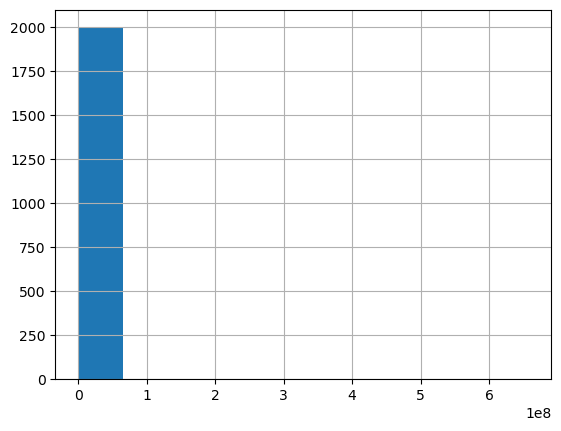

In [13]:
df["Sales"].hist()
plt.show()

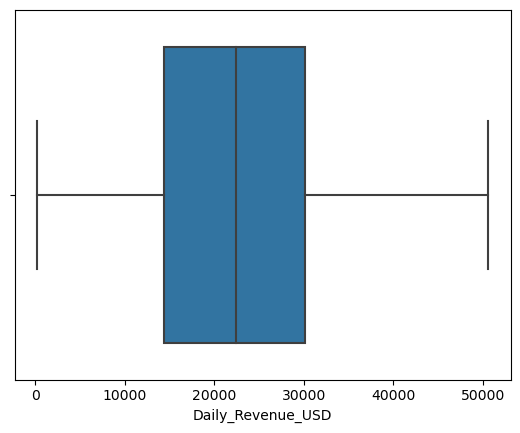

In [14]:
sns.boxplot(x=df["Daily_Revenue_USD"])
plt.show()

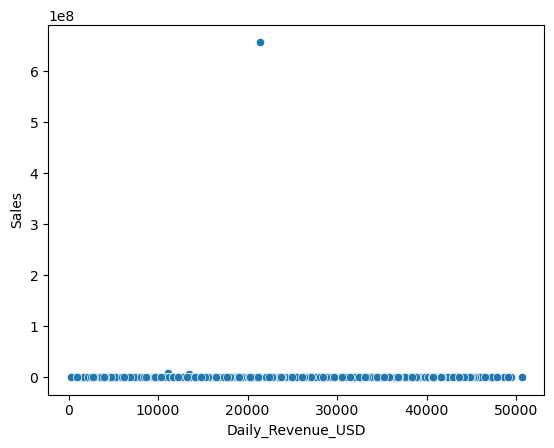

In [15]:
sns.scatterplot(
    x="Daily_Revenue_USD",
    y="Sales",
    data=df
)

plt.show()

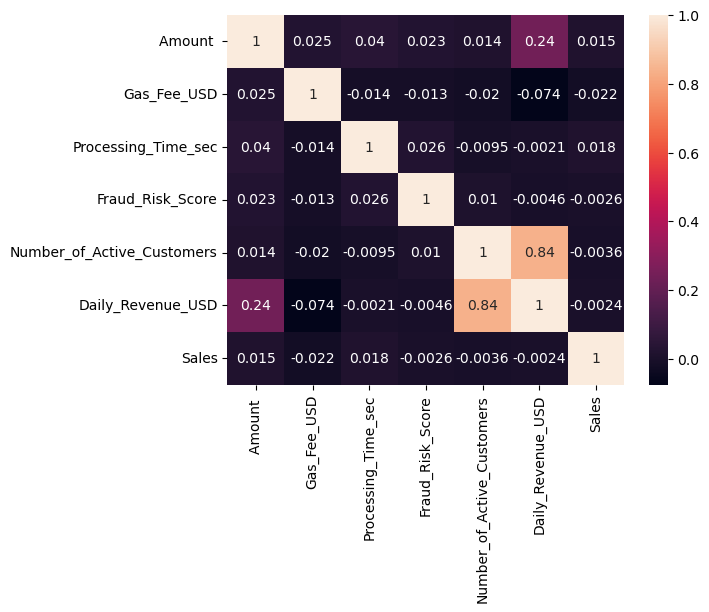

In [16]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)

plt.show()

In [17]:
X = df[["Amount ","Gas_Fee_USD","Daily_Revenue_USD"]]

y = df["Sales"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,

    random_state=42
)

In [33]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [34]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [35]:
predictions = model.predict(X_test)

In [23]:
mean_absolute_error(y_test, predictions)

1663980.5878370414

In [24]:
mean_squared_error(y_test, predictions)

1081286288426534.8

In [25]:
np.sqrt(mean_squared_error(y_test, predictions))

32882917.881881084

In [26]:
r2_score(y_test, predictions)

-0.0025217080669663883

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Amount,0.530030
1,Gas_Fee_USD,0.465415
2,Daily_Revenue_USD,0.004555


<Figure size 800x500 with 0 Axes>

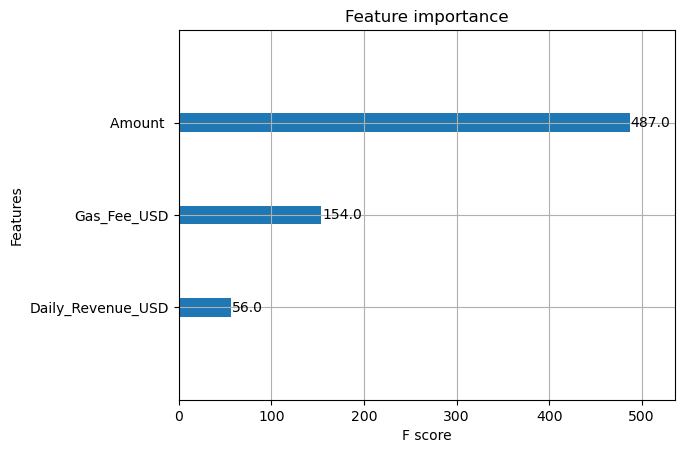

In [38]:
from xgboost import plot_importance

plt.figure(figsize=(8,5))
plot_importance(model)
plt.show()

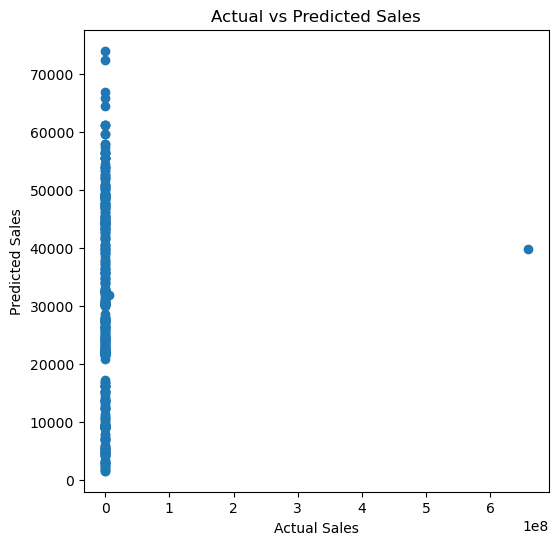

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

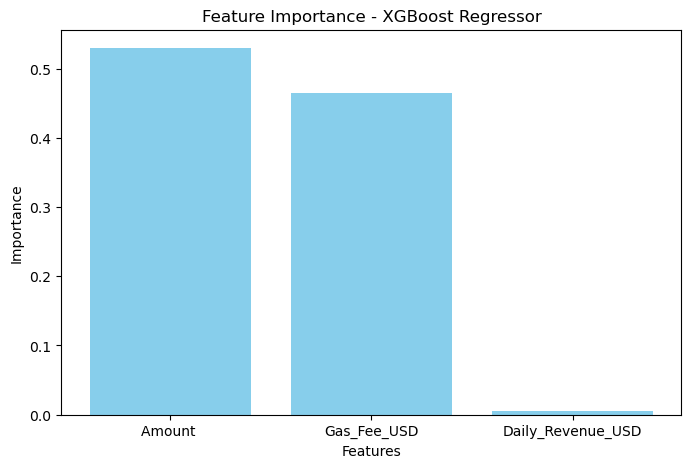

In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"], color="skyblue")
plt.title("Feature Importance - XGBoost Regressor")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

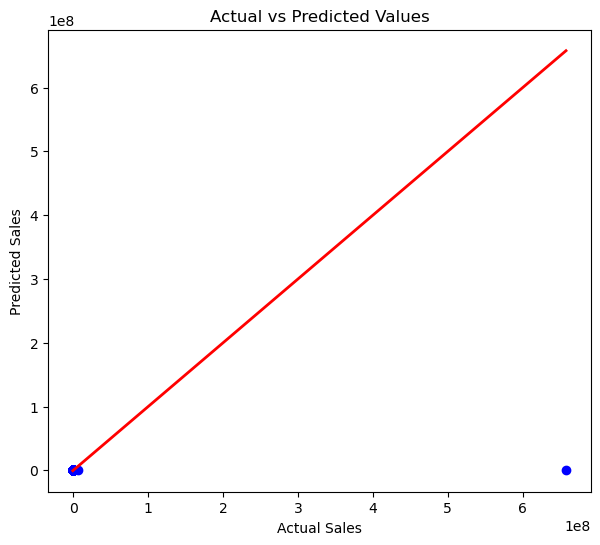

In [41]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, predictions, color="blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()